# Netflix Movies & TV Shows: End-to-End Exploratory Data Analysis (EDA) Using Python

In [2]:
# Importing libraries and datasets:-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_dataset():
    try:
        return pd.read_csv("All datasets/netflix_titles.csv")
    except:
        print("Dataset is not imported")
        return -1;

In [3]:
# Basic informations about dataset:-
df = load_dataset();

df.head()
df.tail()
df.info()    # RangeIndex: 8807 entries, 0 to 8806        and         Data columns (total 12 columns):
df.describe()   # only release_year is in numerical category and rest all are the categorical data's

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
# To check their datatypes:-  dtype: str
df['show_id'].unique()
df['duration'].unique()

<ArrowStringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 221, dtype: str

In [5]:
df.sample(10)
df.describe(include="object")  # by analysing this we can understand that the dataset have some missing values

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11596\2109388068.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")  # by analysing this we can understand that the dataset have some missing values


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [6]:
# Basic overview of dataset dimensions
df.dtypes  # almost everyone is str except one is int64
df.shape   # (8807, 12)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

# Data Quantity Analysis

In [7]:
# number of missing values in a columns:- so there are total 4307 missing values in a table
df.isnull().sum()

# number of duplicated values :- So there is no duplicated rows or columns in a table
df.duplicated(subset=df.columns).sum()     #np.int64(0)
df.duplicated().sum()     #np.int64(0)

# to see the number of unqiue values in each columns:-
df.nunique()

# Overall conclusion:-
    # That yes in our dataset, (we have missing values NaN), (No duplicated rows and columns)

show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

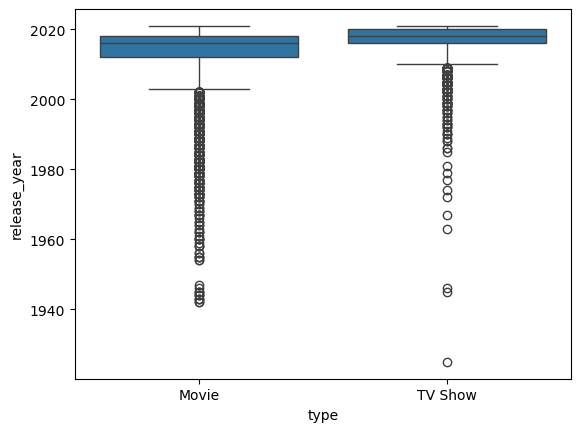

In [8]:
# Checking Outliers:-
sns.boxplot(data=df, x="type", y="release_year")
plt.show()

# We find the amazing thing:- as per this chart, we can see that yes we have outliers but are these outliers are 
# actually an outlier? 
# as per statistical perspective (ans is):- No, these outliers are from 2013 to something around 1940, it means that these movies and shows data 
# are not real. But actually during 1940 there are some classical showes which are existing at that time also, so it is
# just like the historical record's.
# Conclusion --> so statically we have outliers but logically we do not have outliers
# So we should remove them --> No

# Checking Statistical Outliers V/S Logical Justification

In [9]:
# Lets calculate the IQR:-
q1 = df["release_year"].quantile(0.25)
q3 = df["release_year"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - iqr*1.5
upper_bound = q3 + iqr*1.5

ran = upper_bound - lower_bound

outliers = df[(df["release_year"] < lower_bound) | (df["release_year"] > upper_bound)]

print("lower_bound, upper_bound, range:- ", lower_bound, upper_bound, ran)
print(outliers)

lower_bound, upper_bound, range:-  2004.0 2028.0 24.0
     show_id   type              title          director  \
7         s8  Movie            Sankofa      Haile Gerima   
22       s23  Movie    Avvai Shanmughi    K.S. Ravikumar   
24       s25  Movie              Jeans        S. Shankar   
26       s27  Movie     Minsara Kanavu       Rajiv Menon   
41       s42  Movie               Jaws  Steven Spielberg   
...      ...    ...                ...               ...   
8764   s8765  Movie         Wyatt Earp   Lawrence Kasdan   
8766   s8767  Movie                XXx         Rob Cohen   
8768   s8769  Movie  Y Tu Mamá También    Alfonso Cuarón   
8770   s8771  Movie            Yaadein      Subhash Ghai   
8792   s8793  Movie        Young Tiger            Mu Chu   

                                                   cast  \
7     Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
22    Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...   
24    Prashanth, Aishwarya Rai Bachchan, Sri Lak

In [10]:
df["release_year"].describe()
df["release_year"].min()
df["release_year"].max()

2021

In [11]:
"""
# Note --> 
Any movie before 2004 → Outlier
Any movie after 2028 → Outlier (there are none)

so we can see that statistically, yes they are outliers but in reality these are not the harmful outliers because 
we all know that movies before 2004 are exist, and after 2028 they also exist but rightnow we don't have any future data
till now we have movies between 1925 - 2021
"""

"\n# Note --> \nAny movie before 2004 → Outlier\nAny movie after 2028 → Outlier (there are none)\n\nso we can see that statistically, yes they are outliers but in reality these are not the harmful outliers because \nwe all know that movies before 2004 are exist, and after 2028 they also exist but rightnow we don't have any future data\ntill now we have movies between 1925 - 2021\n"

# Data Cleaning:-

In [12]:
df.isnull().sum()
"""
# before filling the values in place of NAN:-
    we have to analyse that whether these missing values are really sensable or not
    ans --> yes
    reason --> 1) many shows don't reveal director and producer, generally they reveal the production houses
    2) many shows don't have the proper cast, so they don't reveal them 
    3) Maybe Netflix may not record the multiple countries 
    4) if date_added is having NaN, then maybe it is due to that the movie is recently added

# so what actions we will take:-
    1) we can leave this as it is or
    2) we can fill these NAN values with "unknown"
    3) but in duration:- there are only 3 missing values it means that it affecting only 0.03% of our data
                -> so yes we can remove the missing duration values using dropna() 
"""

'\n# before filling the values in place of NAN:-\n    we have to analyse that whether these missing values are really sensable or not\n    ans --> yes\n    reason --> 1) many shows don\'t reveal director and producer, generally they reveal the production houses\n    2) many shows don\'t have the proper cast, so they don\'t reveal them \n    3) Maybe Netflix may not record the multiple countries \n    4) if date_added is having NaN, then maybe it is due to that the movie is recently added\n\n# so what actions we will take:-\n    1) we can leave this as it is or\n    2) we can fill these NAN values with "unknown"\n    3) but in duration:- there are only 3 missing values it means that it affecting only 0.03% of our data\n                -> so yes we can remove the missing duration values using dropna() \n'

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [14]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")

df.dropna(subset = ["duration"], axis=0, inplace=True)

In [15]:
df.sample(10)
# df.isnull().sum()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7789,s7790,Movie,Prague,Ashish R. Shukla,"Chandan Roy Sanyal, Elena Kazan, Kumar Mayank,...","India, Switzerland","December 1, 2017",2013,TV-MA,106 min,"Dramas, Independent Movies, International Movies",The chaotic ramblings of a young architect's m...
8225,s8226,Movie,The Breadwinner,Nora Twomey,"Saara Chaudry, Soma Chhaya, Ali Badshah, Soma ...","Ireland, Canada, Luxembourg, United States, Un...","February 20, 2018",2017,PG-13,93 min,"Children & Family Movies, Dramas, Internationa...",A courageous 11-year-old Afghan girl disguises...
7690,s7691,Movie,P.S. I Love You,Richard LaGravenese,"Hilary Swank, Gerard Butler, Lisa Kudrow, Gina...",United States,"April 1, 2019",2007,PG-13,126 min,"Dramas, Romantic Movies",When she loses her beloved husband to a brain ...
1457,s1458,TV Show,Jenni Rivera: Mariposa de Barrio,Unknown,"Angélica Celaya, Gabriel Porras, Rosalinda Rod...",United States,"January 1, 2021",2017,TV-MA,1 Season,"Spanish-Language TV Shows, TV Dramas",This drama follows Mexican-American singer Jen...
5159,s5160,TV Show,Godless,Unknown,"Jeff Daniels, Michelle Dockery, Jack O'Connell...",United States,"November 22, 2017",2017,TV-MA,1 Season,TV Dramas,A ruthless outlaw terrorizes the West in searc...
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,"September 5, 2021",2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...
5991,s5992,Movie,14 Cameras,"Scott Hussion, Seth Fuller","Neville Archambault, Amber Midthunder, Brytnee...",United States,"October 27, 2018",2018,TV-MA,89 min,"Horror Movies, Thrillers","Upping the “13 Cameras” ante, this sequel find..."
7591,s7592,Movie,No Estoy Loca,Nicolás López,"Paz Bascuñán, Marcial Tagle, Antonia Zegers, C...",Chile,"May 4, 2018",2018,TV-MA,116 min,"Comedies, Dramas, International Movies",A woman enters a quirky mental health clinic a...
5951,s5952,Movie,Unspeakable Acts,Linda Otto,"Jill Clayburgh, Brad Davis, Sam Behrens",United States,"October 1, 2011",1990,TV-14,95 min,Dramas,Laurie and Joseph are doctors who interview se...
2548,s2549,TV Show,Trial By Media,Unknown,Unknown,United States,"May 11, 2020",2020,TV-MA,1 Season,"Crime TV Shows, Docuseries","In this true crime docuseries, some of the mos..."


# Univariate Analysis:-

In [16]:
# Q1:- does netflix have more movies or shows ?
movie_count = (df["type"] == "Movie").sum()
show_count = (df["type"] == "TV Show").sum()

if(movie_count > show_count):
    print(f"Netflix have more Movies than shows. Between 1925 to 2021, Netflix have {movie_count} movies")
else:
    print("Netflix have more shows than Movies. Between 1925 to 2021, Netflix have {show_count} shows")
    

Netflix have more Movies than shows. Between 1925 to 2021, Netflix have 6128 movies


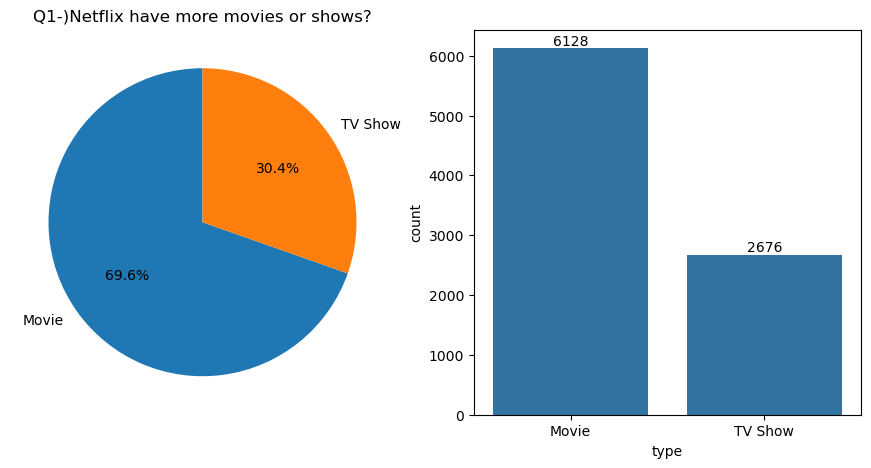

In [17]:
# lets do graphical analysis of above question:-  here, we use PIE PLOT

# plt.subplot(rows, columns, index)
plt.figure(figsize=(11,5))

plt.subplot(1, 2, 1)
count = df['type'].value_counts()
plt.pie(x=count, labels=count.index, startangle=90, autopct="%1.1f%%")
plt.title("Q1-)Netflix have more movies or shows?")

plt.subplot(1, 2, 2)
ax = sns.countplot(data=df, x="type")
ax.bar_label(ax.containers[0])

plt.show()

So we have 15 types of rating:  <ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
  'Unknown', 'TV-Y7-FV',       'UR']
Length: 15, dtype: str


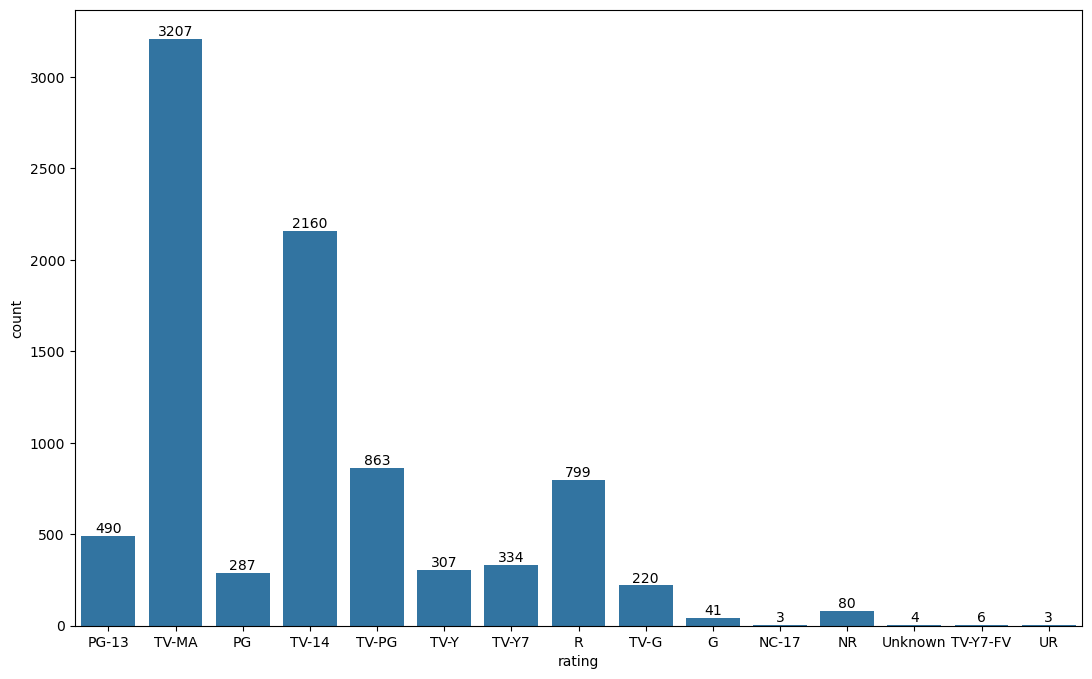

TV-MA --> rating dominate


In [18]:
# Q2:- which rating dominated:- So we use the Count Plot
TypesofRating = df["rating"].nunique()
print(f"So we have {TypesofRating} types of rating: ",df["rating"].unique())

plt.figure(figsize=(13, 8))
ax = sns.countplot(data=df, x='rating')
ax.bar_label(ax.containers[0])
plt.show()

print("TV-MA --> rating dominate")

So right now we have 74 years of data


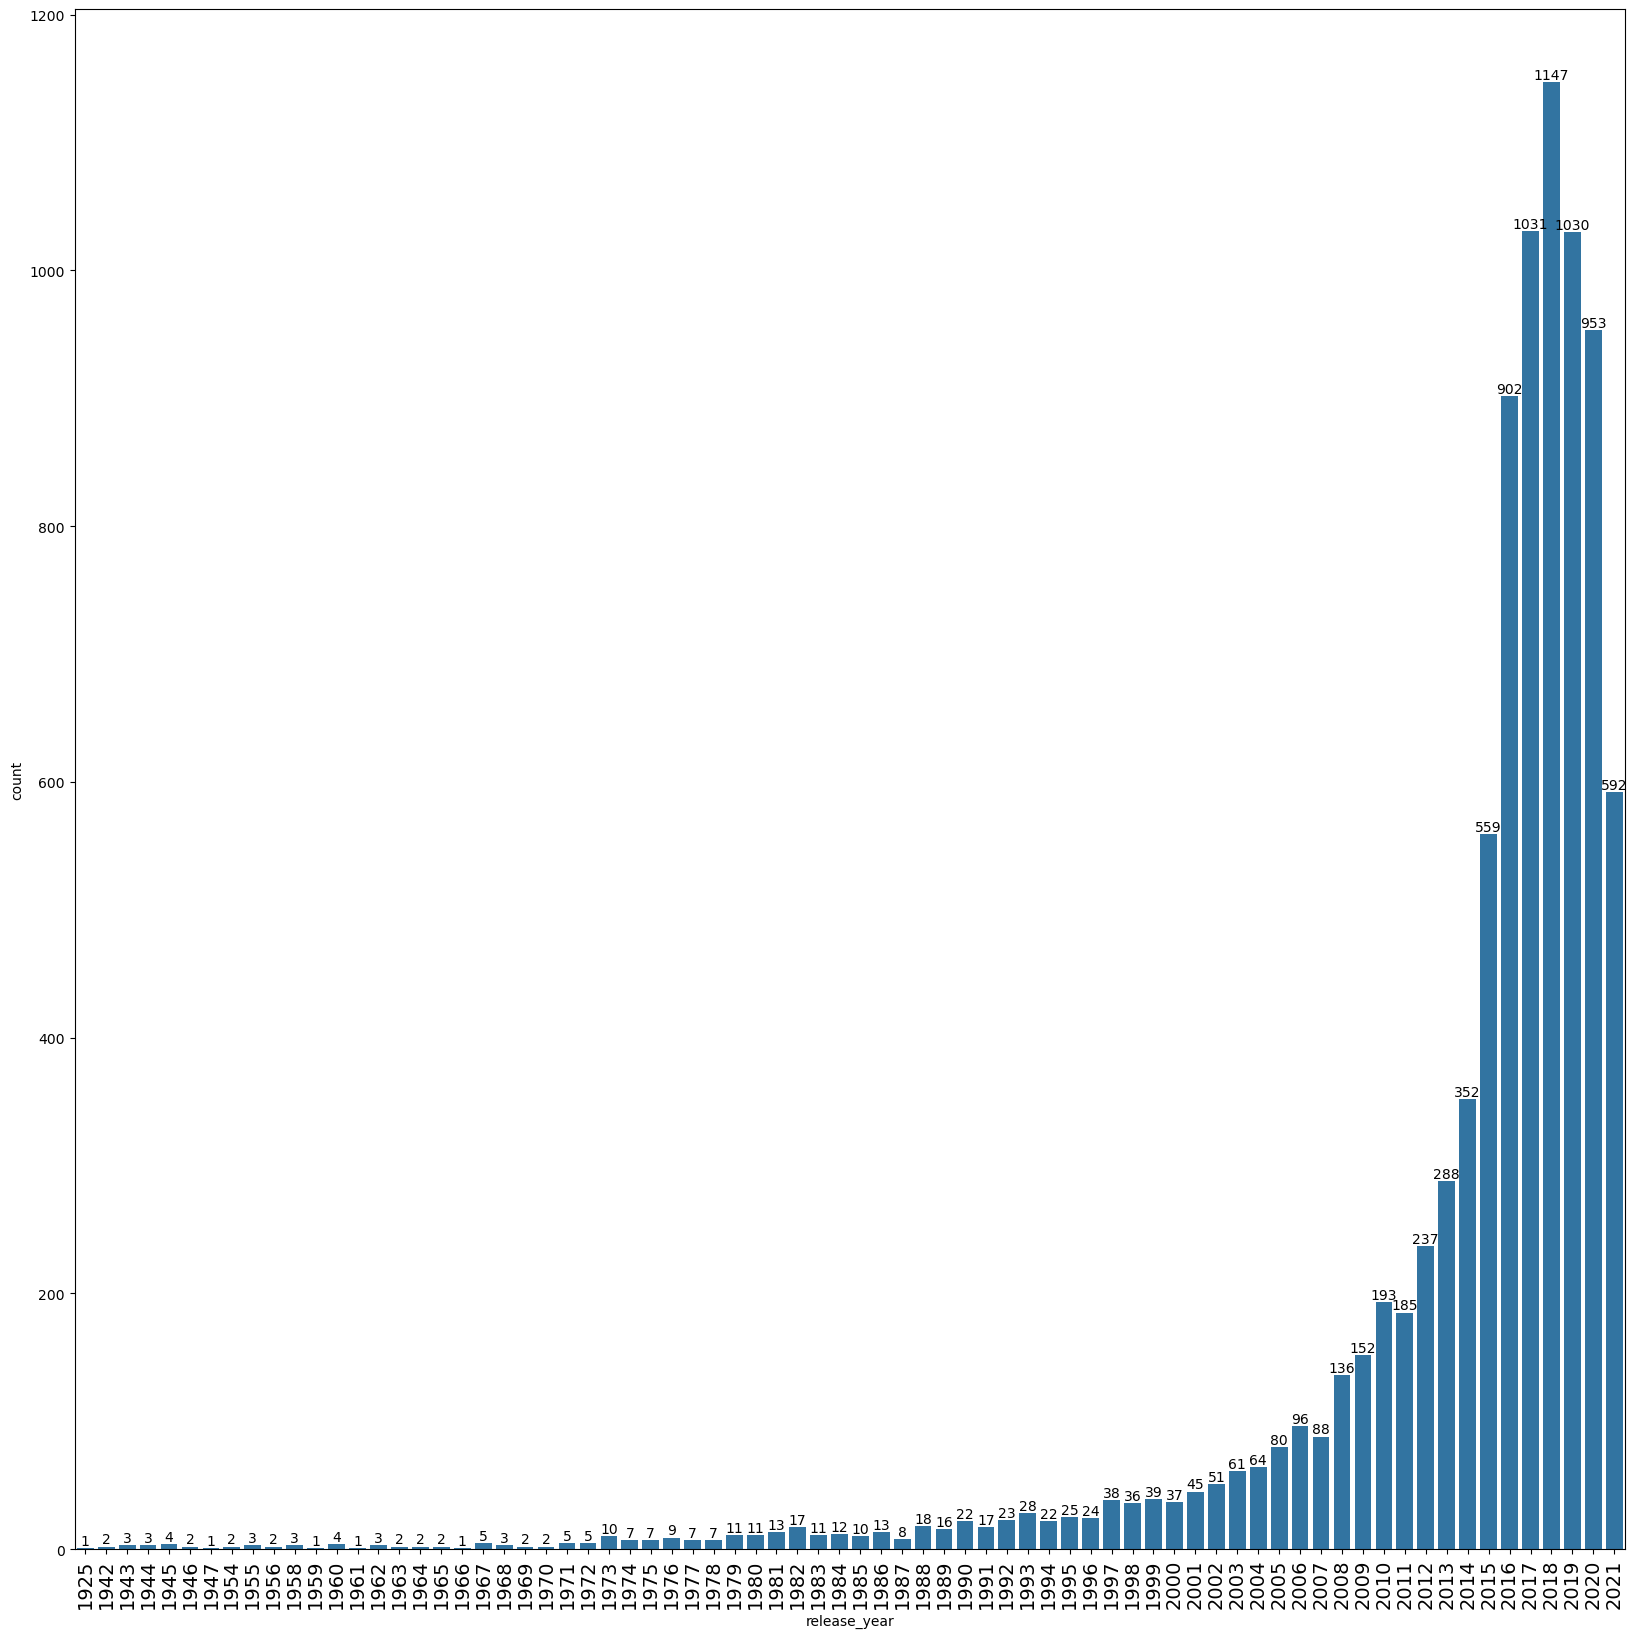

So in 2018 we released 1147 titles


In [19]:
# Q3:- When were most titles released? --> here we use Count plot because right now we are dealing with univariate graphs
print(f"So right now we have {df["release_year"].nunique()} years of data")

plt.figure(figsize=(20, 20))
ax = sns.countplot(data=df, x="release_year", order=df['release_year'].value_counts().sort_index().index)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90, fontsize=14)
plt.show()


print("So in 2018 we released 1147 titles")

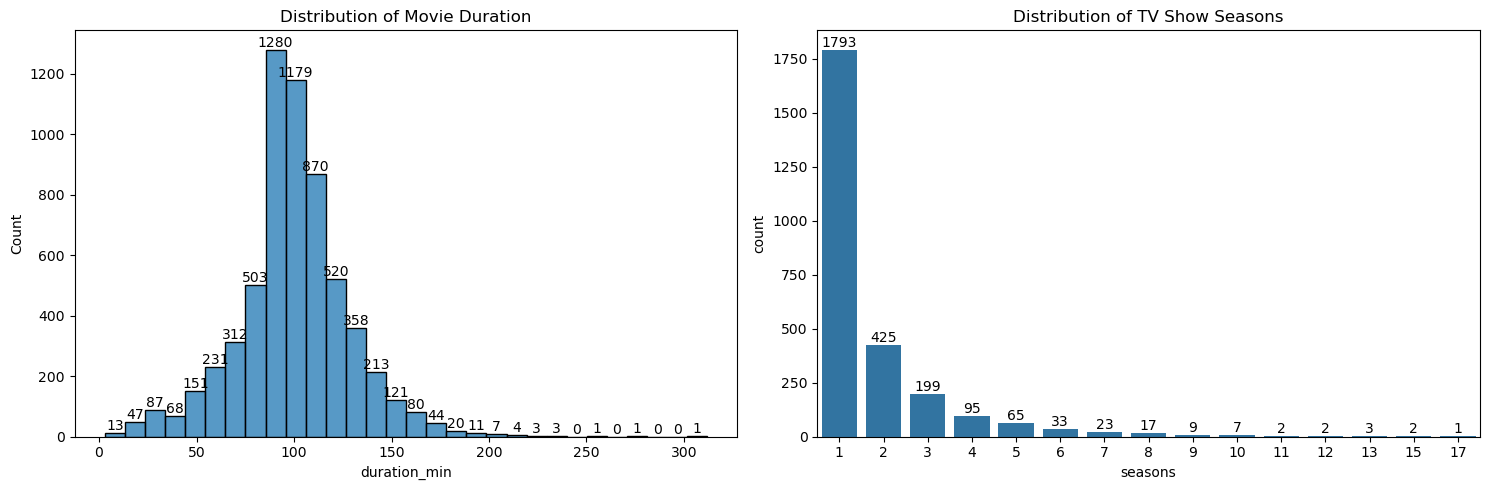

So we have 1280 movies 90 minutes and 1793 TV_Shows of 1 Season

Statistical analysis of Movies Durations
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

Statistical analysis of TV Shows Seasons
count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


In [20]:
# Q4:- Duration Analysis
df["duration"].nunique()

movies = df[df["type"] == "Movie"].copy()
tvshows = df[df["type"] == "TV Show"].copy()

movies["duration_min"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

tvshows["seasons"] = (
    tvshows["duration"]
    .str.replace(" Seasons", "", regex=False)
    .str.replace(" Season", "", regex=False)
    .astype(int)
)



plt.figure(figsize=(15,5))
#----------------------------------- for movies -----------------------------------
plt.subplot(1, 2, 1)
ax = sns.histplot(
    data=movies,
    x="duration_min",
    bins=30
)
ax.bar_label(ax.containers[0])
plt.title("Distribution of Movie Duration")


#---------------------------------- for tv_shows ----------------------------------
plt.subplot(1,2,2)
ax = sns.countplot(
    data=tvshows,
    x="seasons"
)
ax.bar_label(ax.containers[0])
plt.title("Distribution of TV Show Seasons")
plt.tight_layout()
plt.show()


#---------------------------------- Conclusion ----------------------------------
print("So we have 1280 movies 90 minutes and 1793 TV_Shows of 1 Season")
print("\nStatistical analysis of Movies Durations")
print(movies["duration_min"].describe())
print("\nStatistical analysis of TV Shows Seasons")
print(tvshows["seasons"].describe())

# Bivariate Analysis

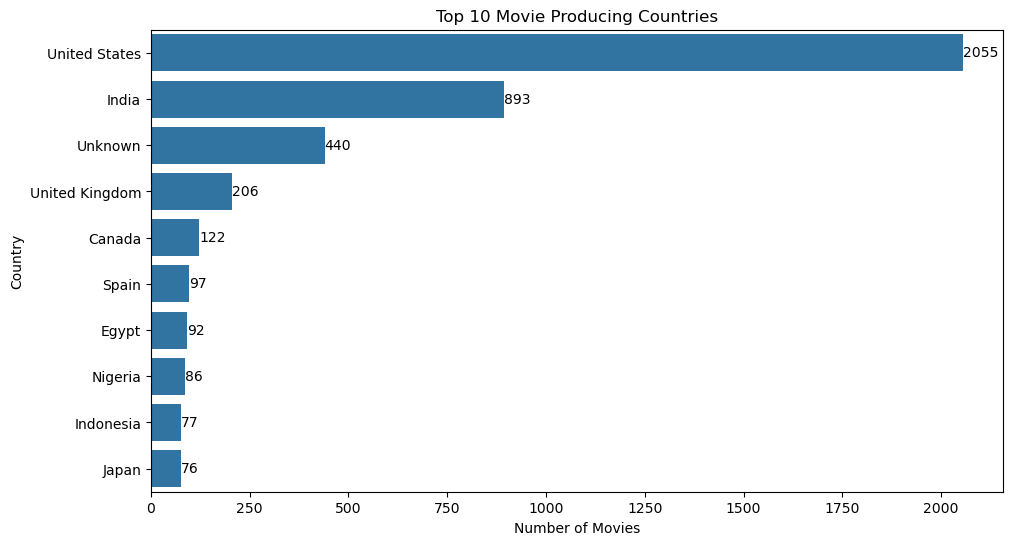

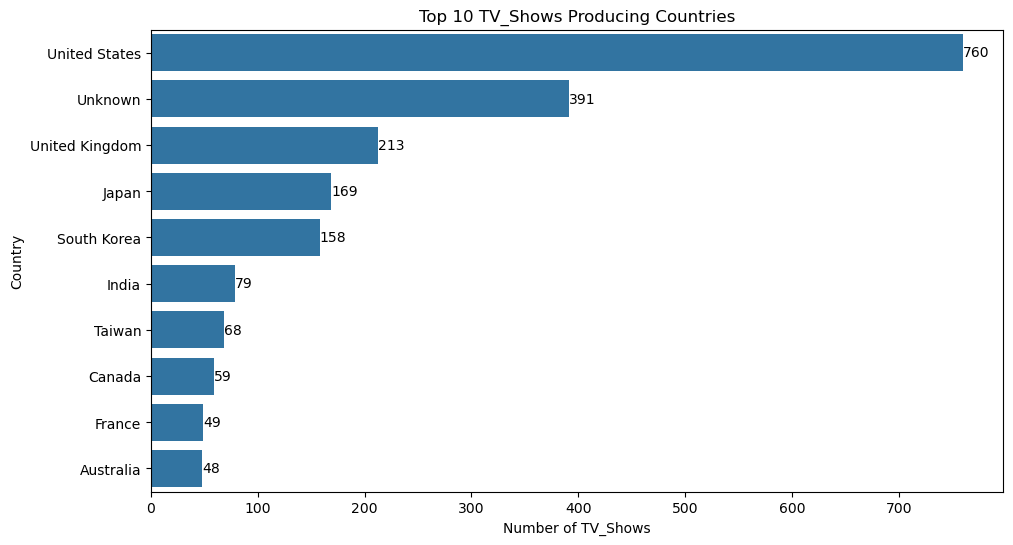

In [21]:
# Q1:- Which countries produce more TV Shows?

movies_df = df[df["type"]=="Movie"]
movies_country_df = movies_df["country"].value_counts()
movies_country_df

shows_df = df[df["type"]=="TV Show"]
show_country_df = shows_df["country"].value_counts()
show_country_df

# printing top 10 countries which produces highest number of movies:-
plt.figure(figsize=(11,6))

top10 = movies_country_df.head(10)
ax = sns.barplot(
    x=top10.values,
    y=top10.index
)
ax.bar_label(ax.containers[0])
plt.title("Top 10 Movie Producing Countries")
plt.xlabel("Number of Movies")
plt.ylabel("Country")

plt.show()

# printing top 10 countries which produces the highest produces the highest number of TV_showes:-
plt.figure(figsize=(11, 6))

top10 = show_country_df.head(10)
ax = sns.barplot(
    x=top10.values,
    y=top10.index
)
ax.bar_label(ax.containers[0])
plt.title("Top 10 TV_Shows Producing Countries")
plt.xlabel("Number of TV_Shows")
plt.ylabel("Country")

plt.show()


In [22]:
df.head()
# df.info()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


     release_year     type  count
0            1925  TV Show      1
1            1942    Movie      2
2            1943    Movie      3
3            1944    Movie      3
4            1945    Movie      3
..            ...      ...    ...
114          2019  TV Show    397
115          2020    Movie    517
116          2020  TV Show    436
117          2021    Movie    277
118          2021  TV Show    315

[119 rows x 3 columns]


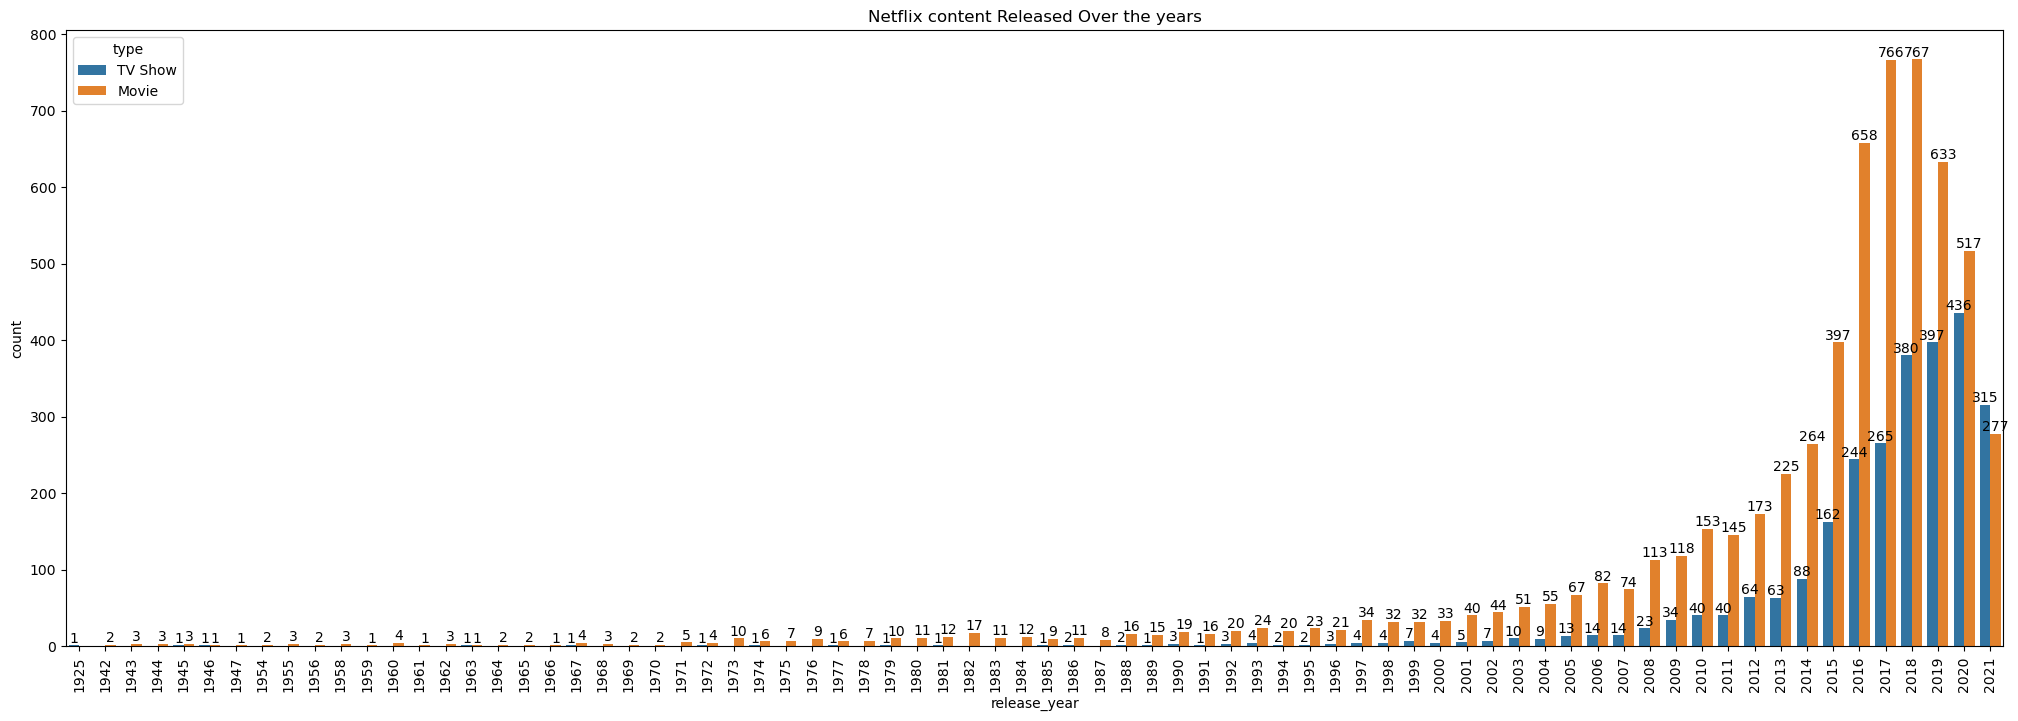

In [23]:
# Q2:- Release_Year vs Type

# aggregation --> it is a pandas concept that is used to add the two or more rows or columns
release = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)
print(release)

plt.figure(figsize=(25, 8))

ax = sns.barplot(
    data=release,
    x = "release_year",
    y = "count",
    hue="type"
)


for container in ax.containers:
    ax.bar_label(container)


plt.xticks(rotation=90)
plt.title("Netflix content Released Over the years")
plt.show()


In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
Name: count, dtype: int64


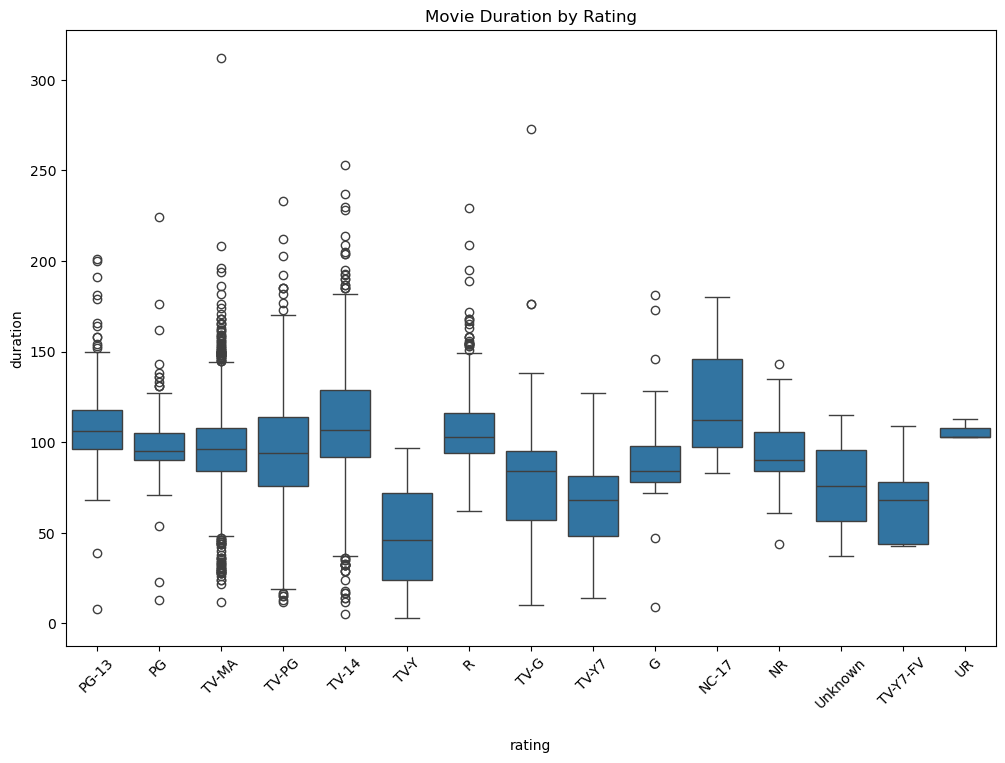

In [25]:
# Q3:- Rating vs Duration
# Do R-rated movies tend to be longer?

# total count of each type of rating:-
rating = df["rating"].value_counts()
print(rating)

movies = df[df["type"]=="Movie"].copy()

# converting the movies duration from string to int:-
movies["duration"] = movies["duration"].str.replace(" min", "").astype(int)

# aggre = (df.groupby(["rating", "duration"]).size().reset_index(name="count"))
# print(aggre)

plt.figure(figsize=(12, 8))
sns.boxplot(data=movies, y="duration", x="rating")

plt.xticks(rotation = 45)
plt.ylabel("duration")
plt.xlabel("rating", labelpad=20)

plt.title("Movie Duration by Rating")
plt.show()


# answer --> R-rated movies generally have runtimes around 100 minutes and tend to be slightly longer than family-oriented ratings such as PG and TV-G.
# However, they are not the longest category overall, as ratings like TV-14 and NC-17 show similar or slightly higher median durations. 
# R-rated movies also exhibit several high-duration outliers, indicating that some R-rated films have exceptionally long runtimes.

# Multivariate Analysis

In [26]:
# Genre , Country, Rating analysis
# Like which type of genre is of what rating given by which country?

# Observations:- all the 3 are categorical data
# so for this large dataset, we have to use the heatmap + crosstab

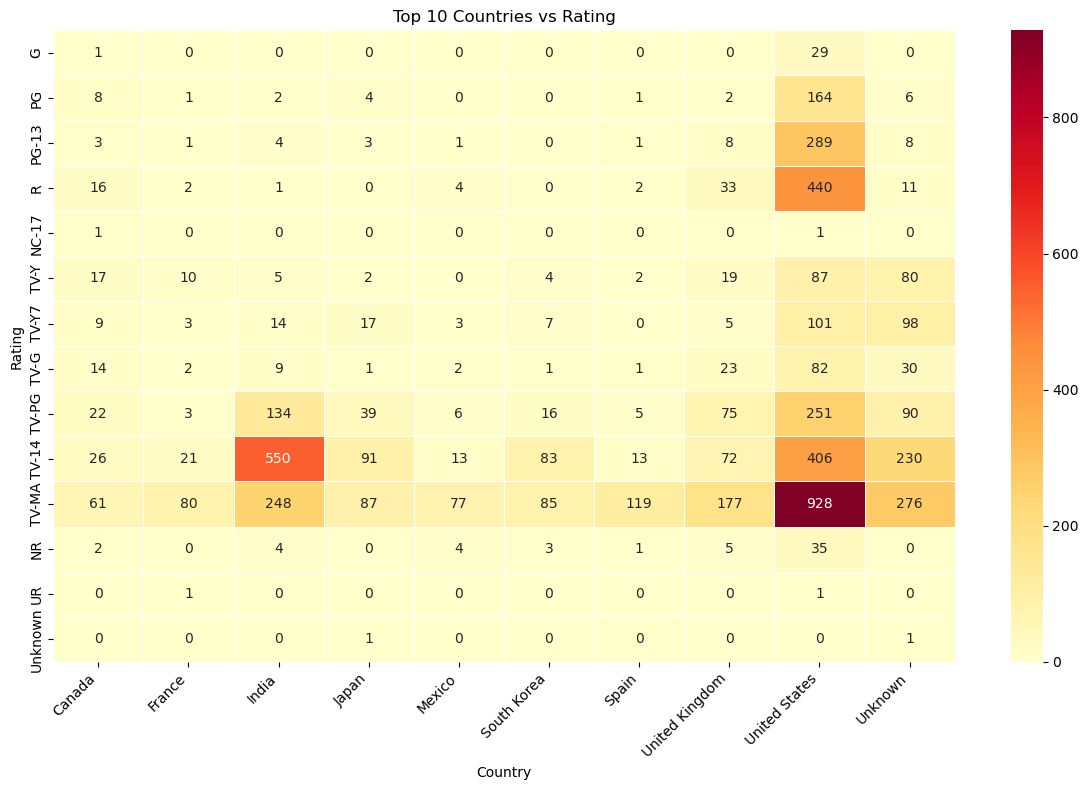

In [27]:
# we Keep it only Top 10 countries
top_countries = df["country"].value_counts().head(10).index
country_df = df[df["country"].isin(top_countries)]

# Create table
table = pd.crosstab(
    country_df["rating"],
    country_df["country"]
)

# Rating order
rating_order = [
    "G", "PG", "PG-13", "R", "NC-17",
    "TV-Y", "TV-Y7", "TV-G",
    "TV-PG", "TV-14", "TV-MA",
    "NR", "UR", "Unknown"
]

table = table.reindex(rating_order)

# Plot
plt.figure(figsize=(12,8))

sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Top 10 Countries vs Rating")
plt.xlabel("Country")
plt.ylabel("Rating")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Time Series Analysis:-

    added_year  count
0       2008.0      2
1       2009.0      2
2       2010.0      1
3       2011.0     13
4       2012.0      3
5       2013.0     10
6       2014.0     23
7       2015.0     73
8       2016.0    416
9       2017.0   1163
10      2018.0   1625
11      2019.0   1999
12      2020.0   1878
13      2021.0   1498


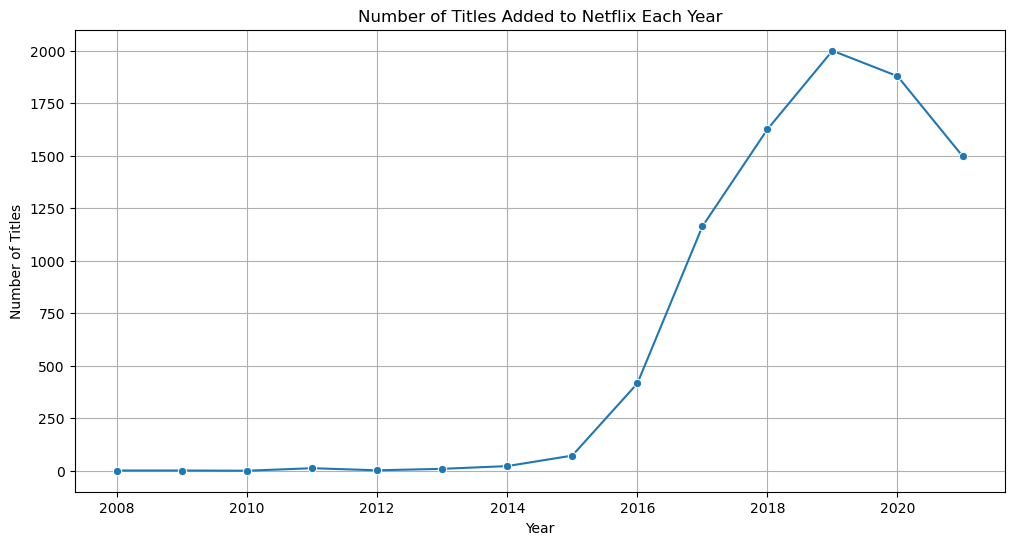

In [28]:
# 1-) How many titles are added each year?

df["date_added"].head()

# lets convert into datetime series
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["added_year"] = df["date_added"].dt.year

# now lets count the titles added each year
title_year = (df.groupby(["added_year"]).size().reset_index(name="count"))
print(title_year)

# now lets plot this trend:- using line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=title_year, x="added_year", y="count", marker='o')

plt.title("Number of Titles Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

   added_month  count
0        April    758
1       August    748
2     December    797
3     February    557
4      January    727
5         July    819
6         June    724
7        March    734
8          May    626
9     November    697
10     October    755
11   September    764


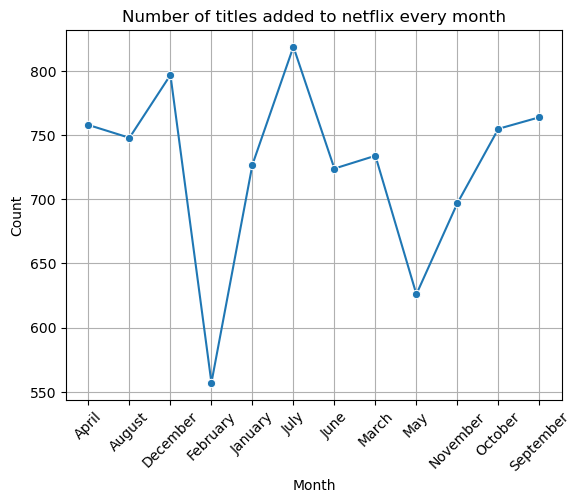

In [29]:
# # 1-) How many titles are added every month?
df["date_added"].head()
date_added = pd.to_datetime(df["date_added"], errors="coerce")
df["added_month"] = df["date_added"].dt.month_name()

# lets count the number of titles added every month
titles_month = (df.groupby("added_month").size().reset_index(name="count"))
print(titles_month)

# lets plot this --> using line chart
sns.lineplot(data=titles_month, x = "added_month", y="count", marker='o')
plt.title("Number of titles added to netflix every month")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Count")

plt.grid(True)
plt.show()

# Director Analysis

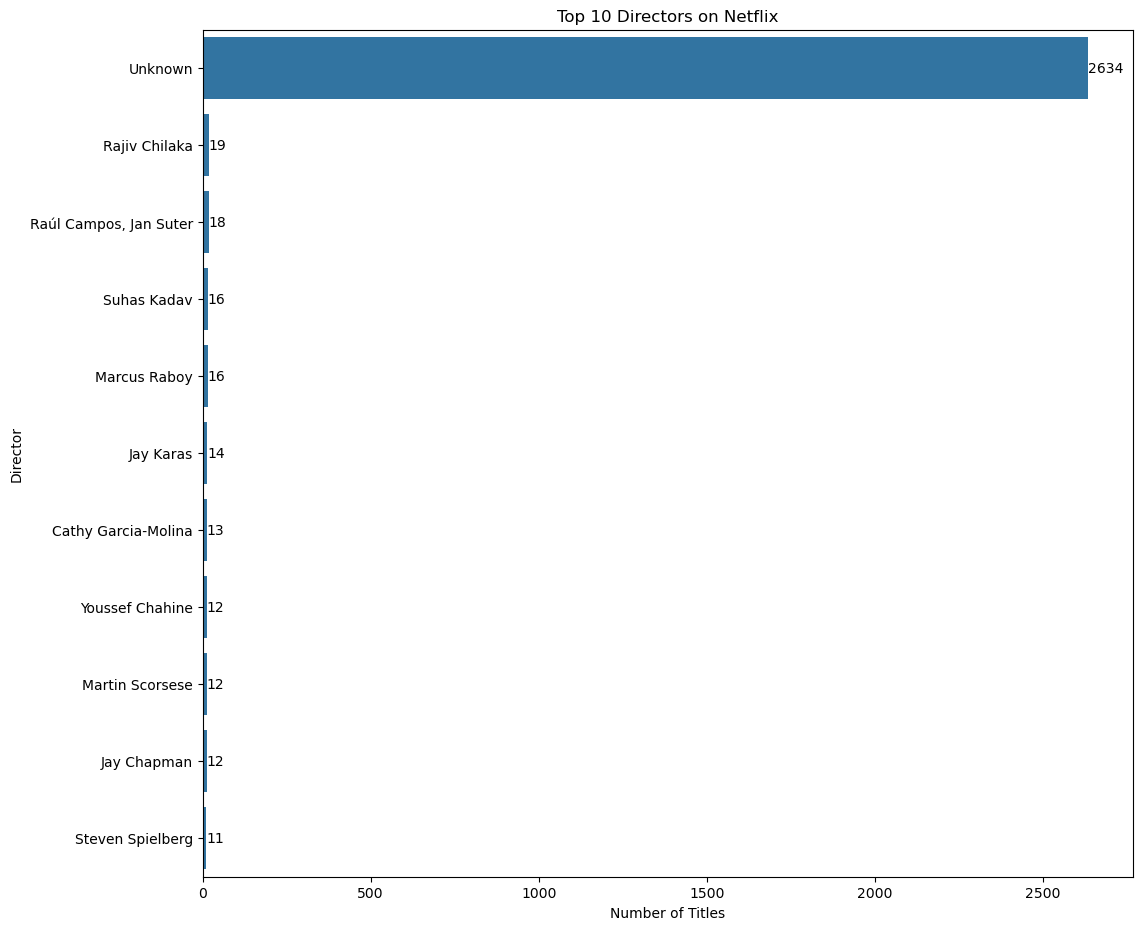

In [43]:
# Top 10 highest titles producing directors :-
df.head()

director_count = (df["director"].value_counts().head(11).reset_index())
director_count.columns = ["director", "count"]

# lets plot the bar chart :-

plt.figure(figsize=(12, 11))
ax = sns.barplot(data=director_count, y="director", x="count")
ax.bar_label(ax.containers[0])

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()


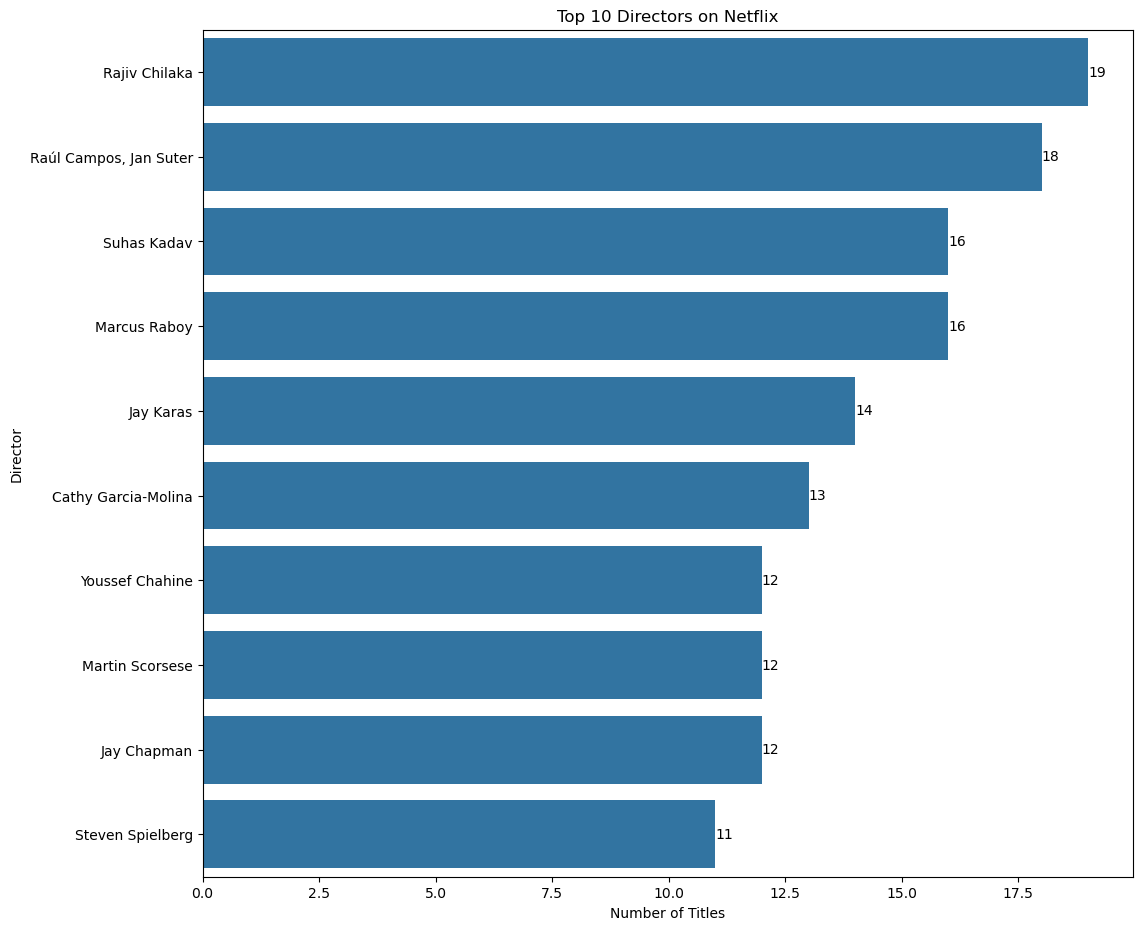

In [47]:
# after removing the unknown directors:-
director_count = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
    .reset_index()
)

director_count.columns = ["director", "count"]

plt.figure(figsize=(12, 11))
ax = sns.barplot(data=director_count, y="director", x="count")
ax.bar_label(ax.containers[0])

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

# Cast Analysis

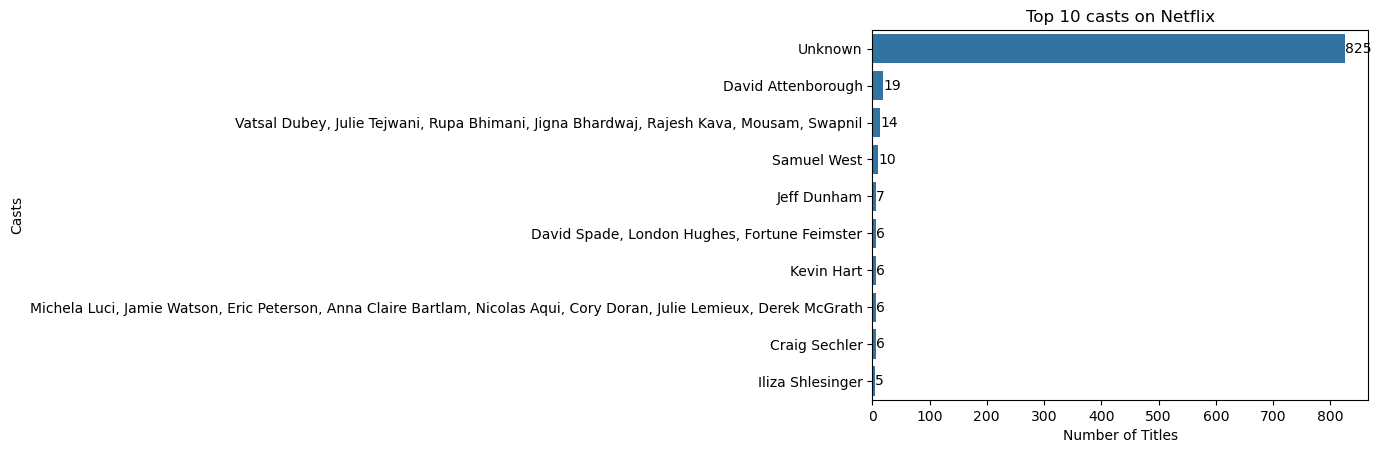

In [52]:
# Q1:- Top 10 casts of Netflix:-
df.head()

actor_analysis = (df["cast"].value_counts().head(10).reset_index(name="count"))
actor_analysis.columns = ["cast", "count"]

ax = sns.barplot(data=actor_analysis, y="cast", x="count")
ax.bar_label(ax.containers[0])


plt.title("Top 10 casts on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Casts")
plt.show()

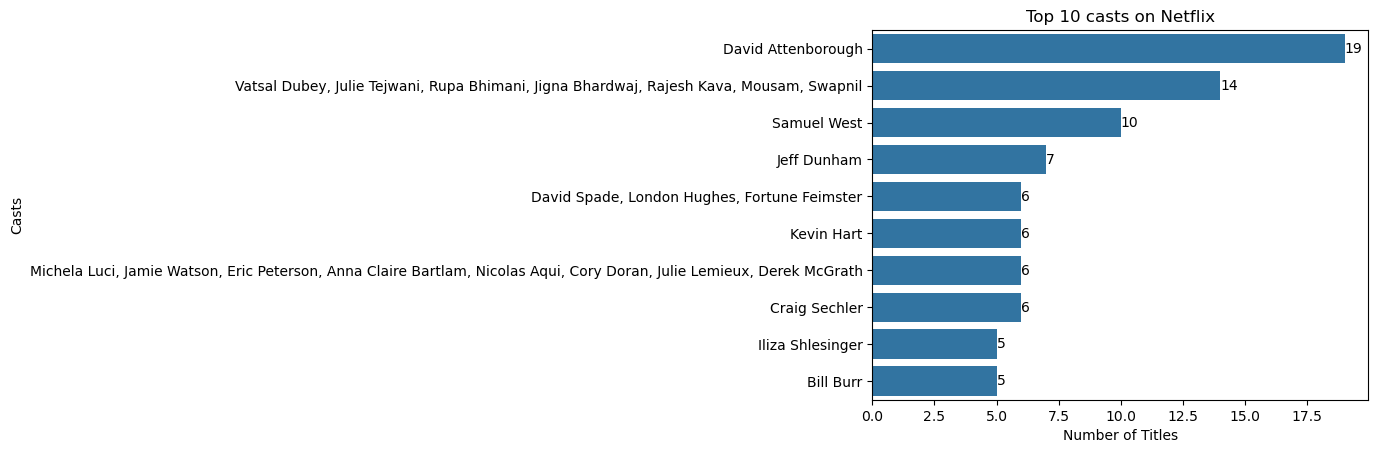

In [54]:
# bar chart after removing the unknown casts:-
actor_analysis = (
    df[df["cast"] != "Unknown"]["cast"]
    .value_counts()
    .head(10)
    .reset_index()
)

actor_analysis.columns = ["cast", "count"]
ax = sns.barplot(data=actor_analysis, y="cast", x="count")
ax.bar_label(ax.containers[0])


plt.title("Top 10 casts on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Casts")
plt.show()

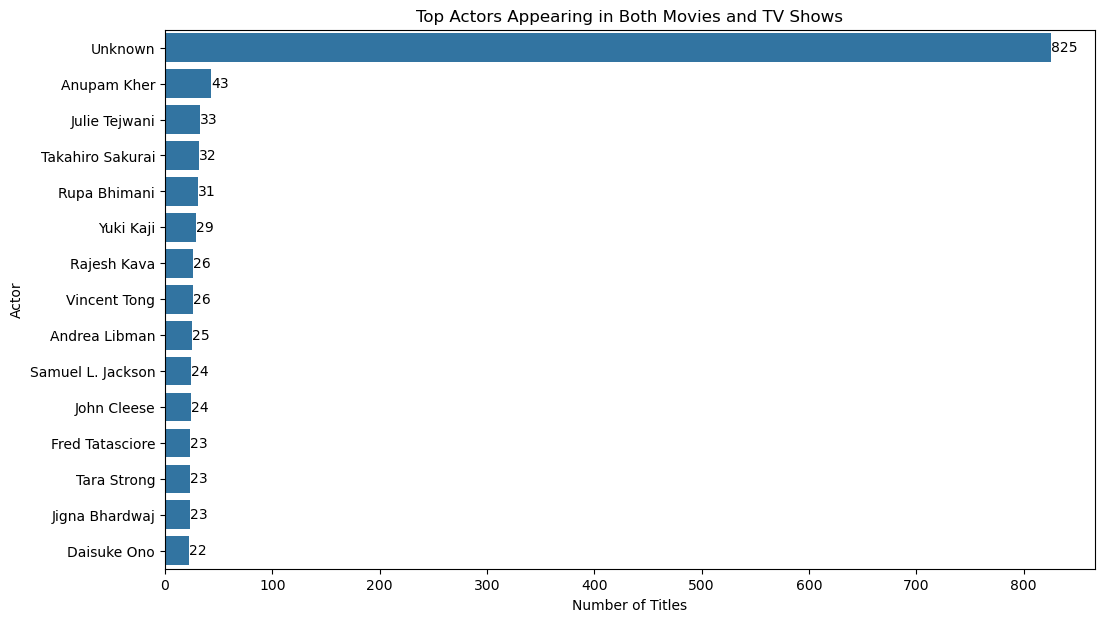

In [58]:
#Q2:- Actors appearing in both Movies and TV Shows
actor_df = df.copy()

# Remove missing cast
actor_df = actor_df.dropna(subset=["cast"])

# Split actors
actor_df["cast"] = actor_df["cast"].str.split(", ")

# One actor per row
actor_df = actor_df.explode("cast")

both = (
    actor_df.groupby("cast")["type"]
    .nunique()
    .reset_index(name="type_count")
)

both = both[both["type_count"] == 2]

# print(both.head())

actors = both["cast"]

# print(actors.tolist())

actor_titles = (
    actor_df[actor_df["cast"].isin(actors)]
    .groupby("cast")
    .size()
    .reset_index(name="Total Titles")
    .sort_values("Total Titles", ascending=False)
)

# print(actor_titles.head(20))

top15 = actor_titles.head(15)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top15,
    y="cast",
    x="Total Titles"
)

ax.bar_label(ax.containers[0])

plt.title("Top Actors Appearing in Both Movies and TV Shows")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

# Business Questions (Very Important):-


In [64]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,September


In [62]:
#1) Does Netflix prioritize Movies or TV shows?
df.head()
df["type"].value_counts()
# answer --> Over the period of time, Netflix Prioritize the Movies over the TV shows

type
Movie      6128
TV Show    2676
Name: count, dtype: int64

In [66]:
# 2) Which genres receive the most investment?

# due to lack of budget or investment columns we can't answer it directly
# but we can say that which genres have the most titles on Netflix

genre_df = df.copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("listed_in")

genre_count = (
    genre_df["listed_in"]
    .value_counts()
    .head(15)
    .reset_index()
)

genre_count.columns = ["Genre", "Number of Titles"]

print(genre_count)
# ans --> International Movies

                       Genre  Number of Titles
0       International Movies              2752
1                     Dramas              2427
2                   Comedies              1674
3     International TV Shows              1351
4              Documentaries               869
5         Action & Adventure               859
6                  TV Dramas               763
7         Independent Movies               756
8   Children & Family Movies               641
9            Romantic Movies               616
10               TV Comedies               581
11                 Thrillers               577
12            Crime TV Shows               470
13                  Kids' TV               451
14                Docuseries               395


In [69]:
# 3-) Which countries contribute the largest content library?
df["country"].value_counts().head(10)
# ans --> United states

country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [71]:
# 4-) Which ratings dominate the platform?
df["rating"].value_counts()
# ans --> TV-MA rating dominated the platform

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
Name: count, dtype: int64

In [73]:
# 5-) Which release years have the most content?
df["release_year"].value_counts().head(10)
# ans --> 2018 have the most contents

release_year
2018    1147
2017    1031
2019    1030
2020     953
2016     902
2021     592
2015     559
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [76]:
# 6-)Which directors appear most frequently?
print("-------------Frequently directors appear------------------")
df["director"].value_counts().head(10)
# ans--> Rajiv Chilaka, 19 times

-------------Frequently directors appear------------------


director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

In [79]:
# 7-)Which actors are featured most often?
print("-------------Actors who featured most often------------------")
actor_df = df.copy()

# Remove missing cast values
actor_df = actor_df.dropna(subset=["cast"])

# Split actors
actor_df["cast"] = actor_df["cast"].str.split(", ")

# Create one row per actor
actor_df = actor_df.explode("cast")

actor_count = (
    actor_df["cast"]
    .value_counts()
    .head(15)
    .reset_index()
)

actor_count.columns = ["Actor", "Number of Titles"]

print(actor_count)

# ans --> Anupam Kher 43 times, SRK 35 times

-------------Actors who featured most often------------------
               Actor  Number of Titles
0            Unknown               825
1        Anupam Kher                43
2     Shah Rukh Khan                35
3      Julie Tejwani                33
4   Naseeruddin Shah                32
5   Takahiro Sakurai                32
6       Rupa Bhimani                31
7       Akshay Kumar                30
8            Om Puri                30
9          Yuki Kaji                29
10  Amitabh Bachchan                28
11      Paresh Rawal                28
12       Boman Irani                27
13       Rajesh Kava                26
14      Vincent Tong                26


In [80]:
# 8-) Which month sees the highest number of new additions?
df["added_month"].value_counts()
# ans--> july is the month where 819 new additions occur

added_month
July         819
December     797
September    764
April        758
October      755
August       748
March        734
January      727
June         724
November     697
May          626
February     557
Name: count, dtype: int64

In [92]:
#9-) Which TV Shows have the highest number of seasons?
shows = df[df["type"] == "TV Show"].copy()

shows["seasons"] = (
    shows["duration"]
    .str.extract(r"(\d+)")
    .astype(int)
)

highest_shows = (
    shows[["title", "seasons"]]
    .sort_values("seasons", ascending=False)
)

print(highest_shows.head(10))

# ans -->  Grey's Anatomy with 17 seasons

                       title  seasons
548           Grey's Anatomy       17
2423            Supernatural       15
4798                    NCIS       15
1354               Heartland       13
4220  COMEDIANS of the world       13
7847            Red vs. Blue       13
4964       Trailer Park Boys       12
5412          Criminal Minds       12
6795                 Frasier       11
6456                  Cheers       11


# Business Insights

# --------Business Recommendations:-

Netflix needs to focus on these recommendations

# Conclusion:-